# Notebook 06 - Model Evaluation & Optimization

## Objective

This notebook performs a detailed evaluation of the best-performing machine learning model for phishing email detection.

The following tasks are performed:

- Load the best trained model
- Evaluate classification performance
- Confusion Matrix
- Cross Validation
- Hyperparameter Tuning
- Error Analysis
- Save Final Model

In [1]:
import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from sklearn.svm import LinearSVC

from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("../data/processed/final_processed_dataset.csv")

tfidf = joblib.load("../models/tfidf_vectorizer.pkl")

In [3]:
X = tfidf.transform(df["clean_text"])

y = df["label"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

In [5]:
best_model = LinearSVC(
    random_state=42
)

best_model.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adj

In [6]:
predictions = best_model.predict(X_test)

In [7]:
print(classification_report(
    y_test,
    predictions
))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      7847
           1       0.98      0.99      0.99      8569

    accuracy                           0.99     16416
   macro avg       0.99      0.99      0.99     16416
weighted avg       0.99      0.99      0.99     16416



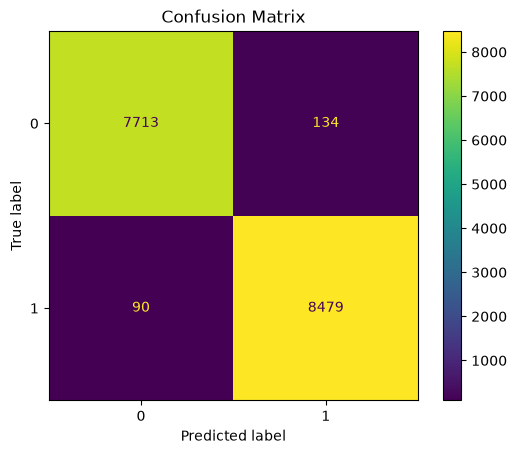

In [8]:
cm = confusion_matrix(
    y_test,
    predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.title("Confusion Matrix")

plt.show()

In [9]:
print("Accuracy :", accuracy_score(y_test,predictions))

print("Precision :", precision_score(y_test,predictions))

print("Recall :", recall_score(y_test,predictions))

print("F1 :", f1_score(y_test,predictions))

Accuracy : 0.98635477582846
Precision : 0.9844421223731569
Recall : 0.9894970241568445
F1 : 0.986963100919567


In [10]:
cv_scores = cross_val_score(
    best_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy",
    n_jobs=1
)

print("Cross Validation Scores")
print(cv_scores)

print()

print("Average Accuracy")

print(cv_scores.mean())

Cross Validation Scores
[0.98575998 0.98644532 0.98621687 0.98667377 0.98553153]

Average Accuracy
0.986125494974109


In [11]:
param_grid = {

    "C":[0.1,0.5,1,2,5]

}

In [12]:
grid = GridSearchCV(

    estimator=LinearSVC(random_state=42),

    param_grid=param_grid,

    cv=5,

    scoring="accuracy",

    n_jobs=1

)

grid.fit(

    X_train,

    y_train

)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LinearSVC(random_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 0.5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with higherva

In [13]:
print("Best Parameters")

print(grid.best_params_)

print()

print("Best Cross Validation Score")

print(grid.best_score_)



Best Parameters
{'C': 0.5}

Best Cross Validation Score
0.9863387145903137


In [14]:
best_model = grid.best_estimator_

In [15]:
pred = best_model.predict(X_test)

In [16]:
print(classification_report(

    y_test,

    pred

))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      7847
           1       0.98      0.99      0.99      8569

    accuracy                           0.99     16416
   macro avg       0.99      0.99      0.99     16416
weighted avg       0.99      0.99      0.99     16416



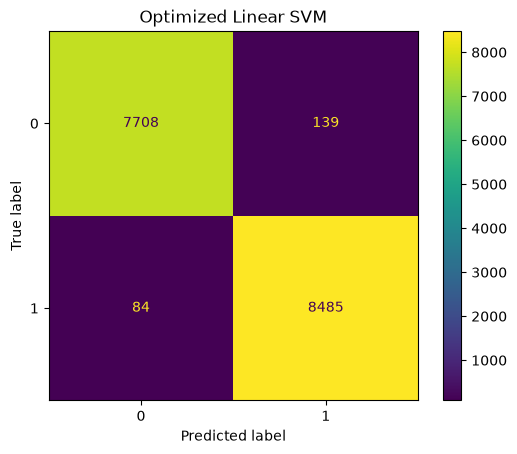

In [17]:
cm = confusion_matrix(

    y_test,

    pred

)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm

)

disp.plot()

plt.title("Optimized Linear SVM")

plt.show()

In [18]:
feature_names = tfidf.get_feature_names_out()

coef = best_model.coef_[0]

In [19]:
top_positive = np.argsort(coef)[-20:]

pd.DataFrame({

    "Word":feature_names[top_positive],

    "Weight":coef[top_positive]

}).sort_values(

    by="Weight",

    ascending=False
)

,Word,Weight
19,josemonkeyorg,2.982986
18,http,1.920277
17,remov,1.755684
16,kindli,1.666185
15,life,1.645223
14,phone mobil,1.615556
13,mobil email,1.607075
12,bank,1.573852
11,tion,1.542985
10,click,1.528937


In [20]:
top_negative = np.argsort(coef)[:20]

pd.DataFrame({

    "Word":feature_names[top_negative],

    "Weight":coef[top_negative]

}).sort_values(

    by="Weight"

)

,Word,Weight
0,enron,-5.090820
1,wrote,-4.678754
2,vinc,-2.999745
3,louis,-2.735475
4,toni,-2.606665
5,thank,-2.513845
6,pm,-2.480272
7,univers,-2.474986
8,linguist,-2.351542
9,fork,-2.243631


In [21]:
joblib.dump(

    best_model,

    "../models/final_model.pkl"

)

['../models/final_model.pkl']

In [ ]:
joblib.dump(

    tfidf,

    "../models/final_tfidf.pkl"print("="*50)




)

['../models/final_tfidf.pkl']

In [23]:
print("="*50)

print("Final Model Saved Successfully")

print("="*50)

Final Model Saved Successfully
